In [1]:
import numpy as np
import matplotlib.pyplot as plt


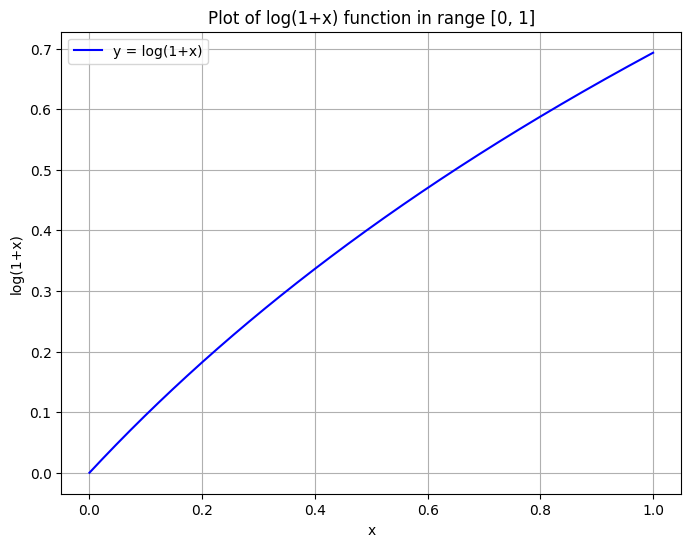

In [2]:
# Generate x values from a small positive number up to 1 to avoid log(0)
x = np.linspace(0, 1, 400)

# Calculate y values using np.log1p (log(1+x))
y = np.log1p(x)

# Create the plot
plt.figure(figsize=(8, 6))
plt.plot(x, y, label='y = log(1+x)', color='blue')
plt.title('Plot of log(1+x) function in range [0, 1]')
plt.xlabel('x')
plt.ylabel('log(1+x)')
plt.grid(True)
plt.legend()
plt.show()


You requested `log base e`, which is the natural logarithm, usually written as `ln(x)` or `log(x)`. It's important to remember that `log(0)` is undefined, so when plotting `log(x)` within the range [0, 1], we must start `x` from a very small positive number to avoid errors and visualize its behavior as it approaches zero.

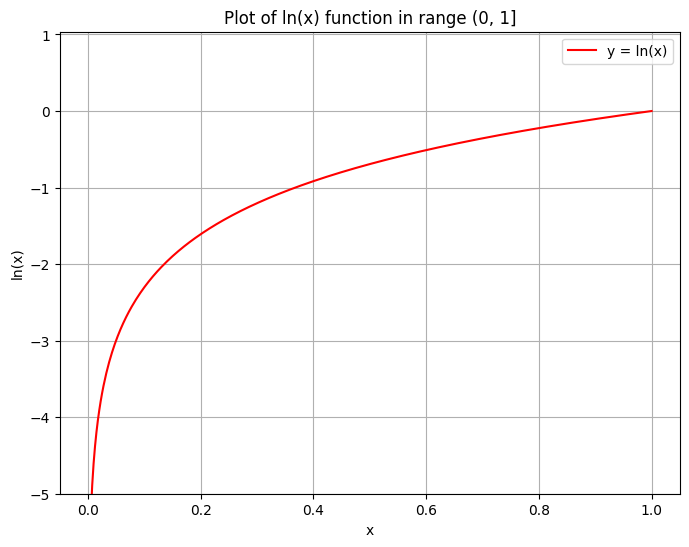

In [3]:
# Generate x values from a very small positive number (e.g., 1e-9) up to 1
x_ln = np.linspace(1e-9, 1, 400)

# Calculate y values using np.log (natural logarithm, base e)
y_ln = np.log(x_ln)

# Create the plot
plt.figure(figsize=(8, 6))
plt.plot(x_ln, y_ln, label='y = ln(x)', color='red')
plt.title('Plot of ln(x) function in range (0, 1]')
plt.xlabel('x')
plt.ylabel('ln(x)')
plt.grid(True)
plt.legend()
plt.ylim(bottom=-5)
plt.show()


Generating synthetic data...
Data generated.
Starting training...
Iteration 0: Cost = 0.5755, Gradient Magnitude = 1.12889787
Iteration 201: Cost = 0.0672, Gradient Magnitude = 0.02802903
Iteration 402: Cost = 0.0589, Gradient Magnitude = 0.01483751
Iteration 603: Cost = 0.0559, Gradient Magnitude = 0.01001933
Iteration 804: Cost = 0.0544, Gradient Magnitude = 0.00745362
Iteration 1005: Cost = 0.0535, Gradient Magnitude = 0.00584167
Iteration 1206: Cost = 0.0529, Gradient Magnitude = 0.00473022
Iteration 1407: Cost = 0.0526, Gradient Magnitude = 0.00391676
Iteration 1608: Cost = 0.0523, Gradient Magnitude = 0.00329617
Iteration 1809: Cost = 0.0521, Gradient Magnitude = 0.00280811
Training finished.

Plotting 11 decision boundaries on a single plot:


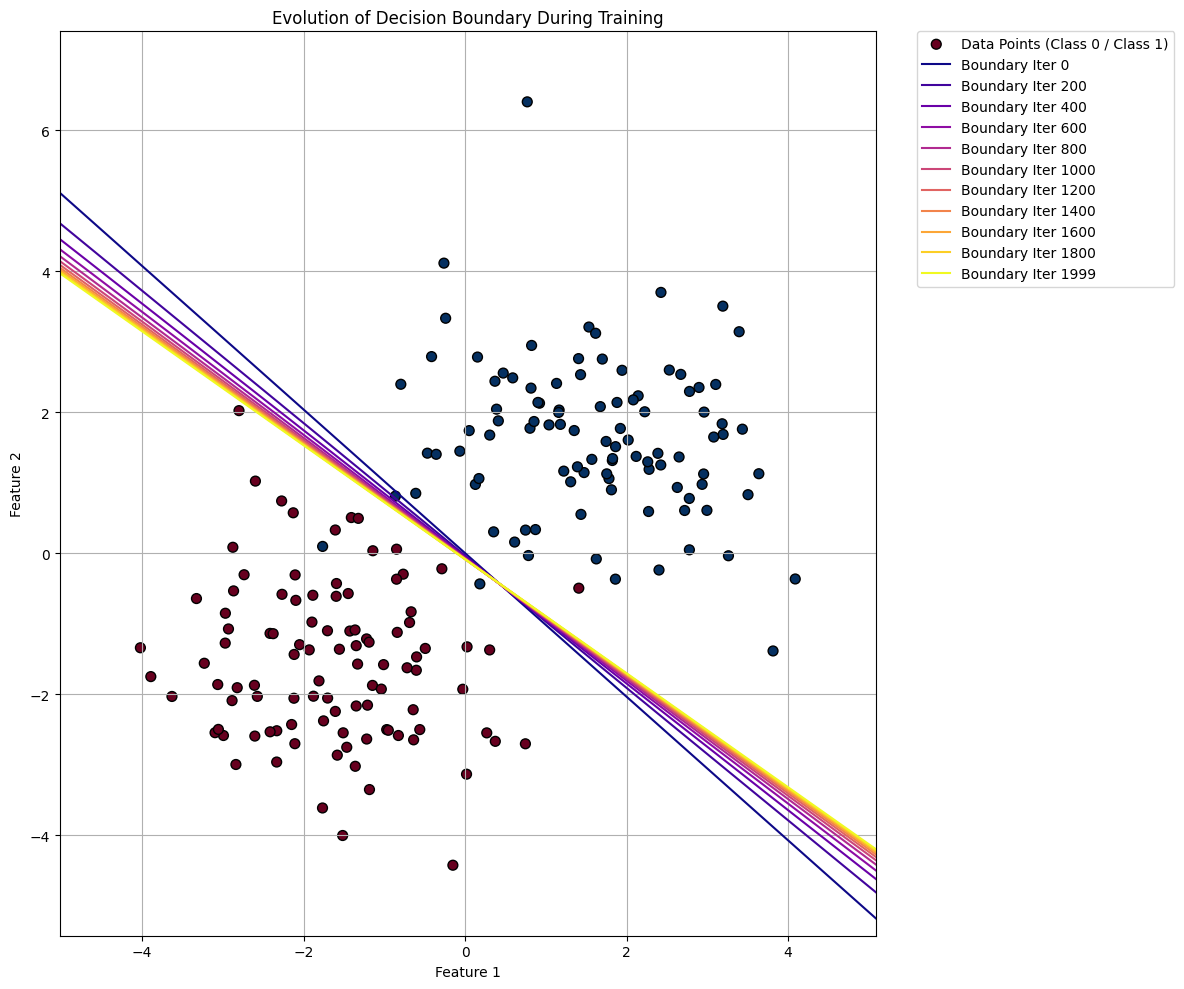

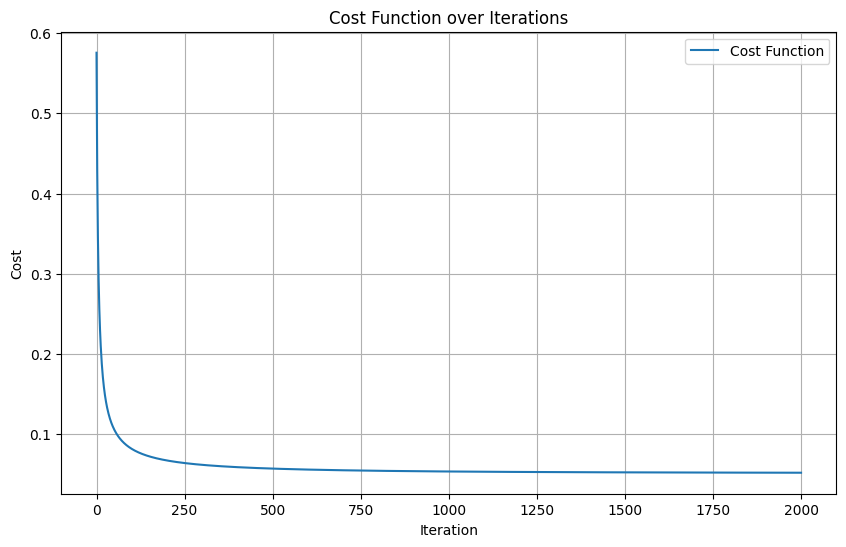

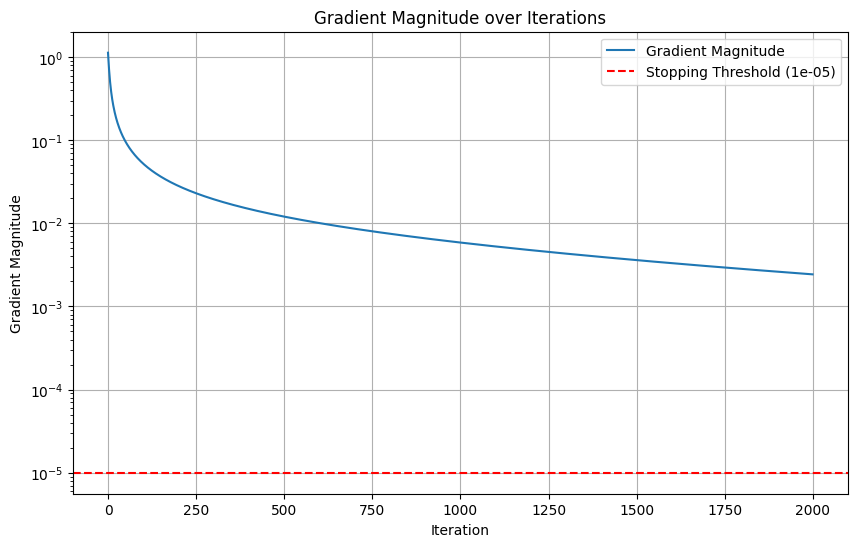


Final training accuracy: 98.50%


In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Set a random seed for reproducibility
np.random.seed(42)

class LogisticRegression:
    def __init__(self, learning_rate=0.1, num_iterations=2000, threshold=0.5, epsilon=1e-5):
        """
        Initializes the Logistic Regression model.

        Args:
            learning_rate (float): The step size for gradient descent.
            num_iterations (int): The maximum number of training iterations.
            threshold (float): The probability threshold for classifying a positive class.
            epsilon (float): Small value to prevent log(0) and as stopping condition for gradient magnitude.
        """
        self.learning_rate = learning_rate
        self.num_iterations = num_iterations
        self.threshold = threshold
        self.epsilon = epsilon  # Stopping condition for gradient magnitude
        self.weights = None
        self.bias = None
        self.costs = []
        self.gradients_magnitude = []
        self.decision_boundaries = []  # Stores (weights, bias, iteration) for plotting

    def sigmoid(self, z):
        """
        The sigmoid activation function.
        """
        return 1 / (1 + np.exp(-z))

    def hypothesis(self, X):
        """
        Computes the hypothesis (predicted probabilities).
        h(X) = sigmoid(X * weights + bias)
        """
        if self.weights is None or self.bias is None:
            raise ValueError("Weights and bias not initialized. Call train() first.")
        z = np.dot(X, self.weights) + self.bias
        return self.sigmoid(z)

    def compute_cost(self, X, y):
        """
        Computes the Binary Cross-Entropy Loss (cost function).
        """
        m = X.shape[0]
        h = self.hypothesis(X)
        # Add a small epsilon to log arguments to prevent log(0) or log(1-0) issues
        cost = (-1/m) * np.sum(y * np.log(h + self.epsilon) + (1 - y) * np.log(1 - h + self.epsilon))
        return cost

    def compute_gradients(self, X, y):
        """
        Computes the gradients of the cost function with respect to weights and bias.
        """
        m = X.shape[0]
        h = self.hypothesis(X)
        dw = (1/m) * np.dot(X.T, (h - y))
        db = (1/m) * np.sum(h - y)
        return dw, db

    def train(self, X, y, plot_every_n_iterations=200):
        """
        Trains the logistic regression model using gradient descent.

        Args:
            X (np.ndarray): Feature matrix.
            y (np.ndarray): Target vector.
            plot_every_n_iterations (int): How often to save model parameters for boundary plotting.
        """
        # Initialize weights and bias to zeros
        num_features = X.shape[1]
        self.weights = np.zeros(num_features)
        self.bias = 0.0 # Use float for bias

        print("Starting training...")
        for i in range(self.num_iterations):
            dw, db = self.compute_gradients(X, y)

            # Calculate gradient magnitude for stopping condition
            grad_magnitude = np.sqrt(np.sum(dw**2) + db**2)
            self.gradients_magnitude.append(grad_magnitude)

            # Update weights and bias using gradient descent
            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db

            # Store cost
            cost = self.compute_cost(X, y)
            self.costs.append(cost)

            # Store decision boundary for visualization at specified intervals
            if i % plot_every_n_iterations == 0 or i == self.num_iterations - 1:
                self.decision_boundaries.append((self.weights.copy(), self.bias.copy(), i))

            # Stopping condition: absolute value of gradient magnitude < epsilon
            if grad_magnitude < self.epsilon:
                print(f"Training stopped early at iteration {i}: Gradient Magnitude = {grad_magnitude:.8f} (below {self.epsilon})")
                # Ensure the final boundary is saved if not already
                if not (i == self.num_iterations - 1 and (i % plot_every_n_iterations == 0)):
                    self.decision_boundaries.append((self.weights.copy(), self.bias.copy(), i))
                break

            if i % (self.num_iterations // 10 + 1) == 0: # Print progress roughly 10 times
                print(f"Iteration {i}: Cost = {cost:.4f}, Gradient Magnitude = {grad_magnitude:.8f}")
        print("Training finished.")

    def predict_proba(self, X):
        """
        Predicts probabilities for the positive class.
        """
        return self.hypothesis(X)

    def predict(self, X):
        """
        Predicts class labels (0 or 1) based on the threshold.
        """
        probabilities = self.predict_proba(X)
        return (probabilities >= self.threshold).astype(int)

    def plot_decision_boundary(self, X, y, weights, bias, iteration_info=""):
        """
        Plots the data points and the decision boundary.
        """
        plt.figure(figsize=(8, 6))
        # Plot data points, colored by their true class
        plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdBu, marker='o', s=50, edgecolors='k', label='Data Points')

        # Create a meshgrid for plotting the decision boundary
        x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
        y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
        xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                             np.arange(y_min, y_max, 0.02))

        # Calculate the decision function Z = X*weights + bias
        Z = np.dot(np.c_[xx.ravel(), yy.ravel()], weights) + bias
        Z = Z.reshape(xx.shape)

        # Plot the decision boundary (where Z = 0)
        plt.contour(xx, yy, Z, levels=[0], colors='black', linestyles='--', alpha=0.7, label='Decision Boundary')
        plt.title(f'Decision Boundary {iteration_info}')
        plt.xlabel('Feature 1')
        plt.ylabel('Feature 2')
        plt.legend()
        plt.xlim(x_min, x_max)
        plt.ylim(y_min, y_max)
        plt.grid(True)
        plt.show()

# --- 1. Generate Synthetic Data for Binary Classification ---
print("Generating synthetic data...")
num_samples = 200
# Features
X_data = np.random.randn(num_samples, 2)
# Target labels
y_data = np.array([0] * (num_samples // 2) + [1] * (num_samples // 2))

# Shift the classes to make them somewhat separable
X_data[:num_samples//2, :] -= 1.5 # Class 0 centered around (-1.5, -1.5)
X_data[num_samples//2:, :] += 1.5 # Class 1 centered around (1.5, 1.5)

# Add some overlap/noise to make it more realistic and not perfectly separable
noise = np.random.randn(num_samples, 2) * 0.7
X_data += noise
print("Data generated.")

# --- 2. Model Training ---
lr_model = LogisticRegression(learning_rate=0.1, num_iterations=2000, epsilon=1e-5)
lr_model.train(X_data, y_data, plot_every_n_iterations=200)

# --- 3. Visualize Decision Boundaries at different stages (on a single plot) ---
print(f"\nPlotting {len(lr_model.decision_boundaries)} decision boundaries on a single plot:")

plt.figure(figsize=(12, 10))
# Plot data points, colored by their true class
plt.scatter(X_data[:, 0], X_data[:, 1], c=y_data, cmap=plt.cm.RdBu, marker='o', s=50, edgecolors='k', label='Data Points (Class 0 / Class 1)')

x_min, x_max = X_data[:, 0].min() - 1, X_data[:, 0].max() + 1
y_min, y_max = X_data[:, 1].min() - 1, X_data[:, 1].max() + 1

# Generate a color map for the boundaries based on the number of stored boundaries
line_colors = plt.cm.plasma(np.linspace(0, 1, len(lr_model.decision_boundaries)))

for i, (weights_iter, bias_iter, iteration_num) in enumerate(lr_model.decision_boundaries):
    # The decision boundary is where X * weights + bias = 0
    # For 2 features (x1, x2), this is: w0*x1 + w1*x2 + b = 0
    # We can solve for x2: x2 = (-w0*x1 - b) / w1
    if weights_iter[1] != 0: # Avoid division by zero for vertical lines
        x_line = np.linspace(x_min, x_max, 100)
        y_line = (-weights_iter[0] * x_line - bias_iter) / weights_iter[1]
        plt.plot(x_line, y_line, color=line_colors[i], linestyle='-', linewidth=1.5,
                 label=f'Boundary Iter {iteration_num}')
    elif weights_iter[0] != 0: # Handle nearly vertical lines (weights[1] close to zero)
        # x1 = (-w1*x2 - b) / w0 (constant x1)
        x_line_const = (-weights_iter[1] * y_min - bias_iter) / weights_iter[0] # Calculate x for a y
        plt.axvline(x=x_line_const, color=line_colors[i], linestyle='-', linewidth=1.5,
                    label=f'Boundary Iter {iteration_num}')
    # If both weights are zero, there's no meaningful boundary to plot, skip.

plt.title('Evolution of Decision Boundary During Training')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)
plt.grid(True)
# Adjust legend to be outside the plot area if there are many entries
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

# --- 4. Plot Cost Function over Iterations ---
plt.figure(figsize=(10, 6))
plt.plot(lr_model.costs, label='Cost Function')
plt.title('Cost Function over Iterations')
plt.xlabel('Iteration')
plt.ylabel('Cost')
plt.grid(True)
plt.legend()
plt.show()

# --- 5. Plot Gradient Magnitude over Iterations ---
plt.figure(figsize=(10, 6))
plt.plot(lr_model.gradients_magnitude, label='Gradient Magnitude')
plt.title('Gradient Magnitude over Iterations')
plt.xlabel('Iteration')
plt.ylabel('Gradient Magnitude')
plt.yscale('log') # Use log scale to better visualize small magnitudes
plt.axhline(y=lr_model.epsilon, color='r', linestyle='--', label=f'Stopping Threshold ({lr_model.epsilon})')
plt.grid(True)
plt.legend()
plt.show()

# --- 6. Final Prediction and Accuracy ---
y_pred = lr_model.predict(X_data)
accuracy = np.mean(y_pred == y_data) * 100
print(f"\nFinal training accuracy: {accuracy:.2f}%")

# --- 7. Plot Final Decision Boundary (This is now redundant if the above plot is comprehensive, but keeping it for comparison if needed) ---
# lr_model.plot_decision_boundary(X_data, y_data, lr_model.weights, lr_model.bias, 'Final')
# To avoid multiple plots, I will comment out the single final plot, as the combined plot shows the final state.

Generating synthetic multi-class data...
Multi-class data generated.
Starting training for Multi-Class Logistic Regression...
Iteration 0: Cost = 0.9821, Gradient Magnitude = 1.56109548
Learning Rate:  0.045000000000000005
Iteration 1001: Cost = 0.0418, Gradient Magnitude = 0.01630872
Learning Rate:  0.04050000000000001
Iteration 2002: Cost = 0.0349, Gradient Magnitude = 0.00950048
Learning Rate:  0.03645000000000001
Iteration 3003: Cost = 0.0322, Gradient Magnitude = 0.00711319
Learning Rate:  0.03280500000000001
Iteration 4004: Cost = 0.0306, Gradient Magnitude = 0.00589713
Learning Rate:  0.02952450000000001
Iteration 5005: Cost = 0.0296, Gradient Magnitude = 0.00516298
Learning Rate:  0.02657205000000001
Iteration 6006: Cost = 0.0289, Gradient Magnitude = 0.00467348
Learning Rate:  0.02391484500000001
Iteration 7007: Cost = 0.0284, Gradient Magnitude = 0.00432499
Learning Rate:  0.021523360500000012
Iteration 8008: Cost = 0.0280, Gradient Magnitude = 0.00406512
Learning Rate:  0.01

/tmp/ipykernel_5282/2484821077.py:147: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_light = plt.cm.get_cmap('Paired', self.num_classes)
/tmp/ipykernel_5282/2484821077.py:148: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_bold = plt.cm.get_cmap('Dark2', self.num_classes)


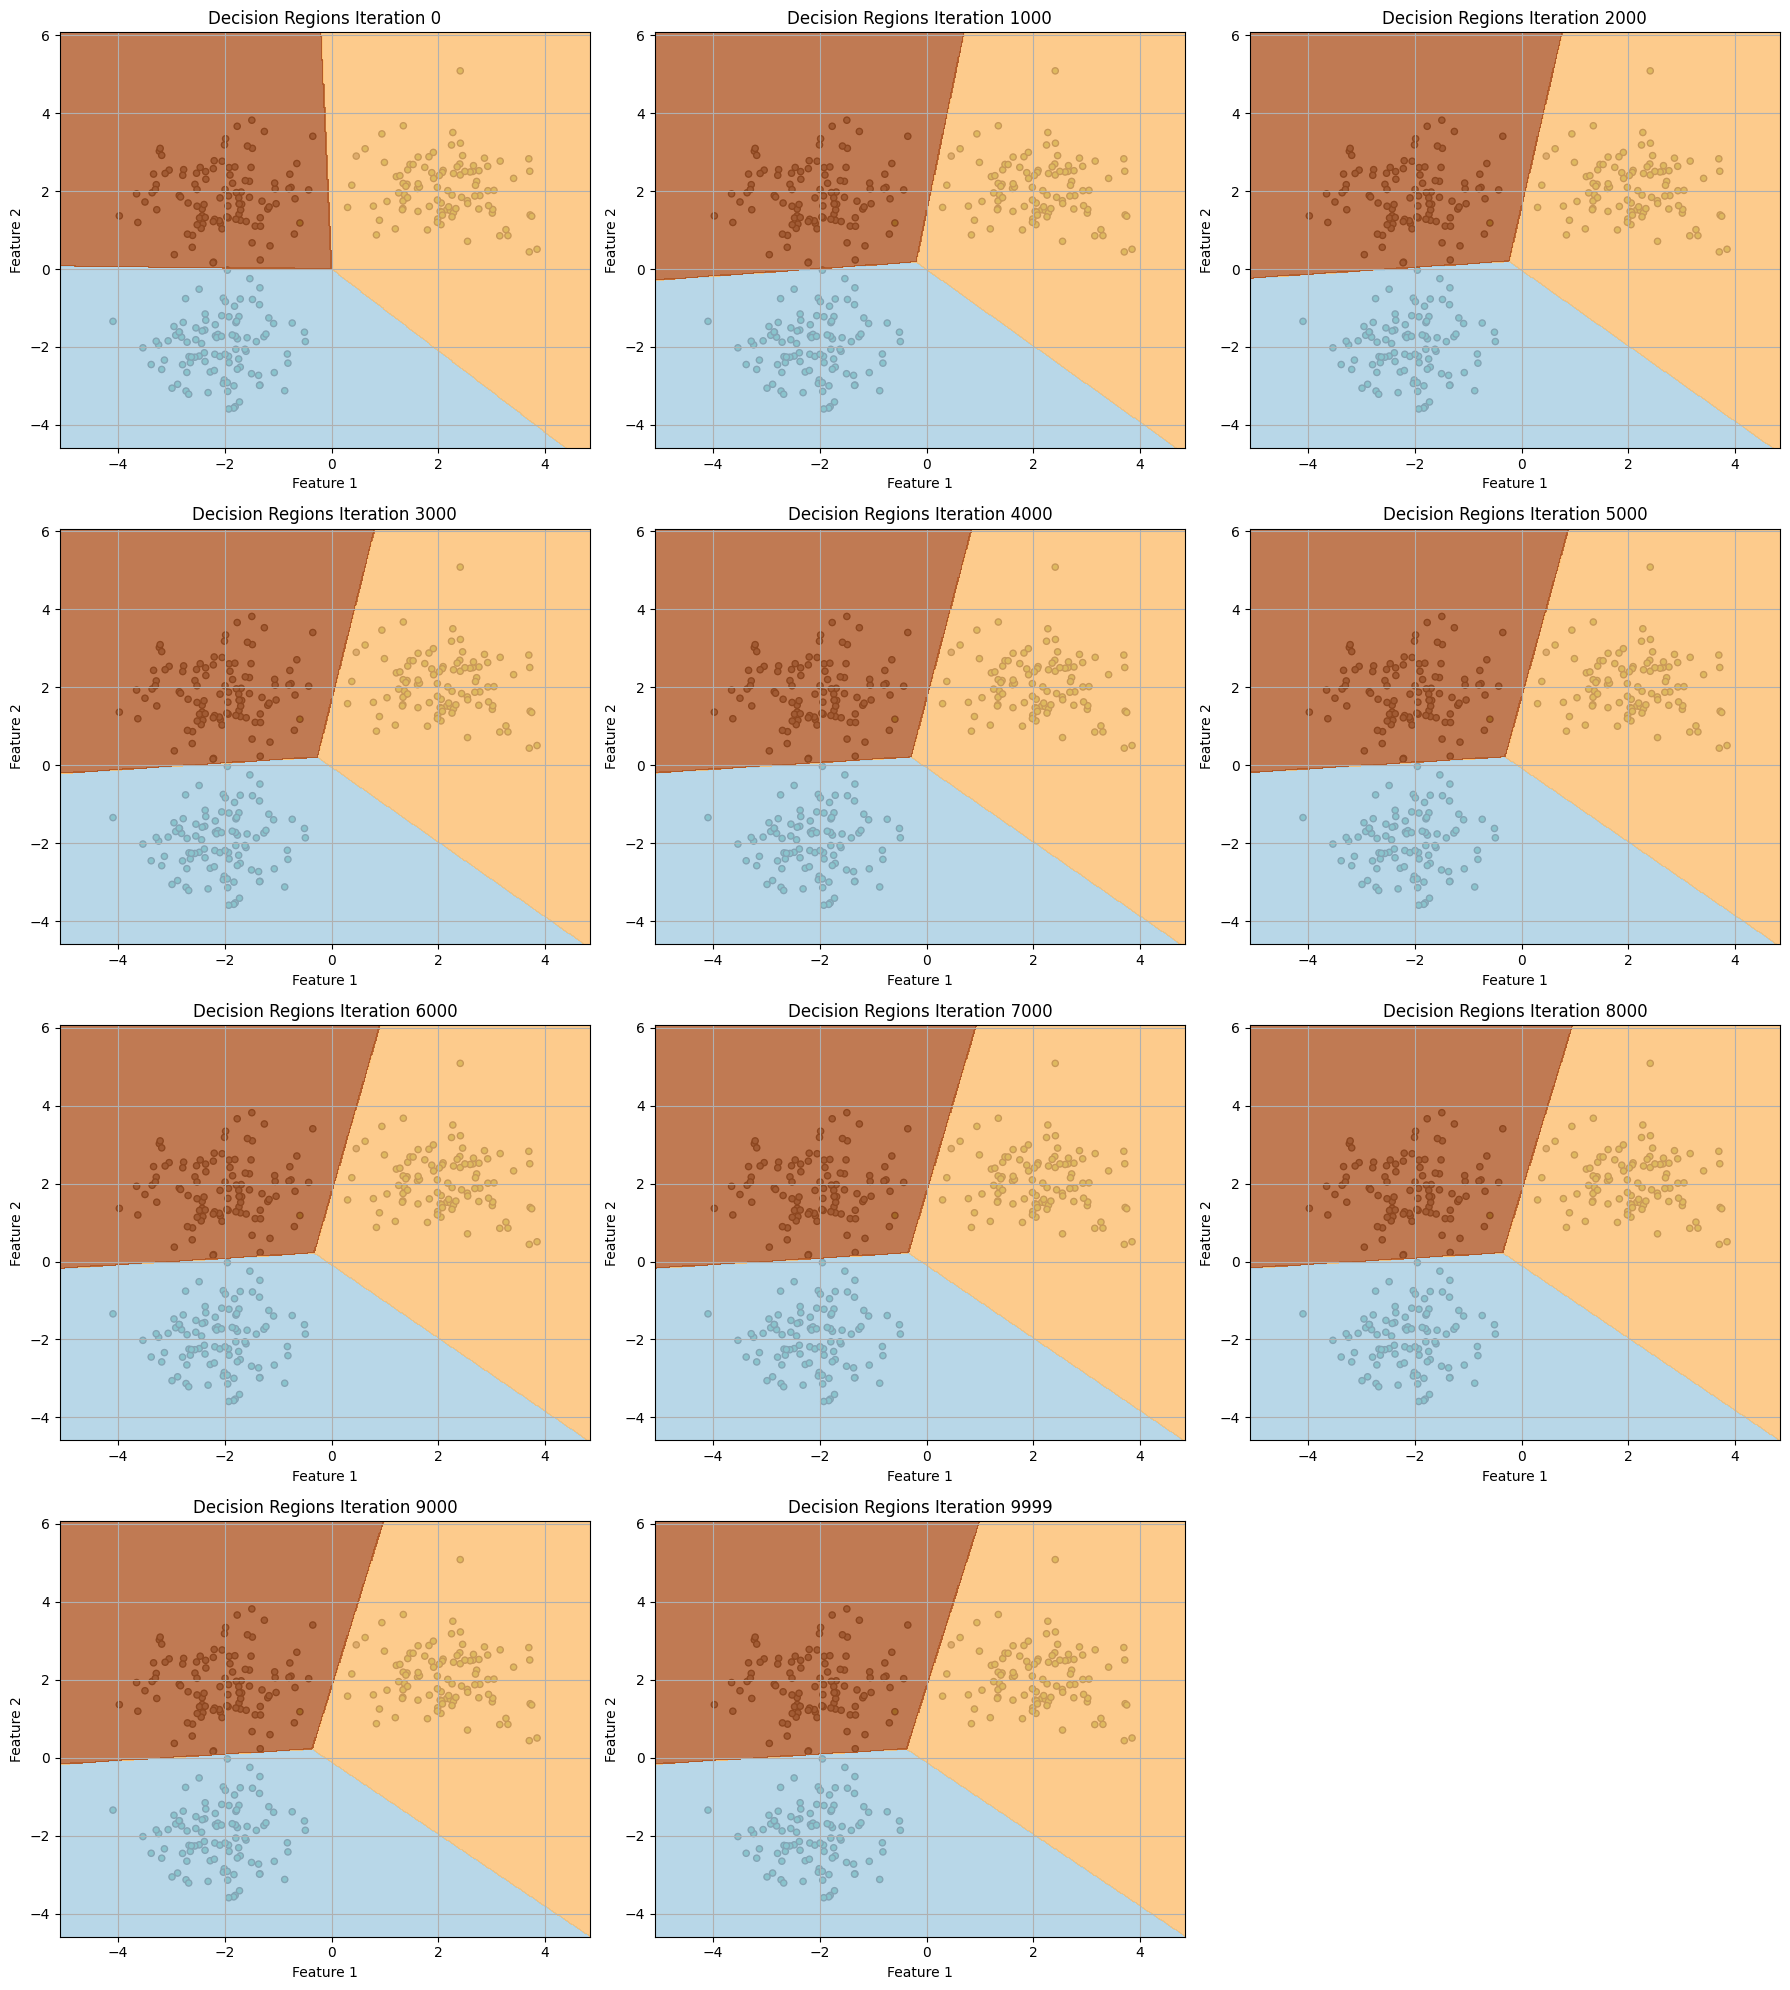

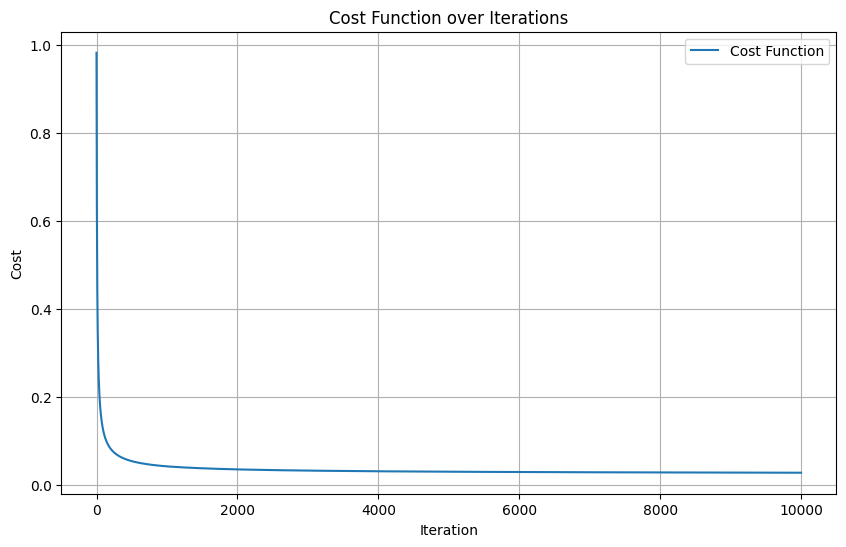

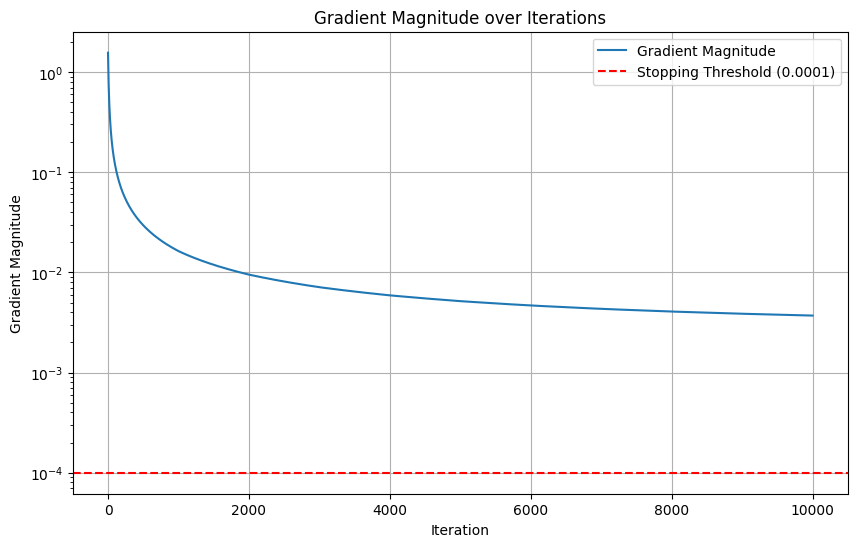


Final training accuracy (Multi-Class): 99.00%


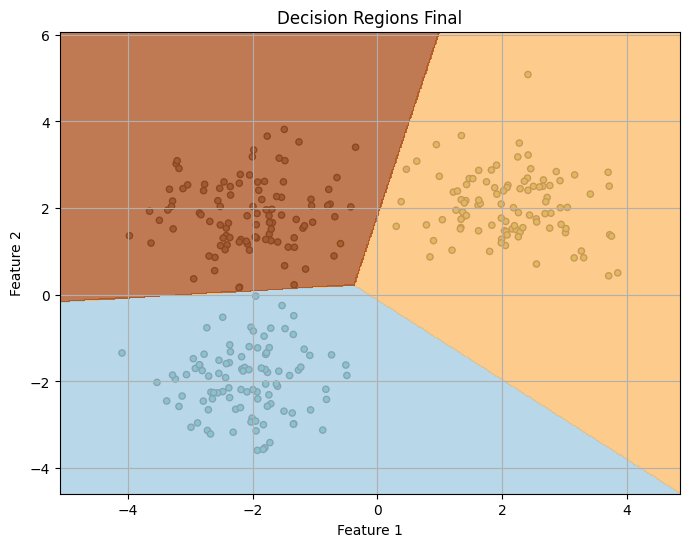

In [18]:
import numpy as np
import matplotlib.pyplot as plt

# Set a random seed for reproducibility
np.random.seed(42)

class MultiClassLogisticRegression:
    def __init__(self, learning_rate=0.1, num_iterations=5000, epsilon=1e-5, decay_rate=0.9):
        """
        Initializes the Multi-Class Logistic Regression model.

        Args:
            learning_rate (float): The step size for gradient descent.
            num_iterations (int): The maximum number of training iterations.
            epsilon (float): Small value to prevent log(0) and as stopping condition for gradient magnitude.
        """
        self.learning_rate = learning_rate
        self.num_iterations = num_iterations
        self.epsilon = epsilon  # Stopping condition for gradient magnitude
        self.weights = None
        self.bias = None
        self.costs = []
        self.gradients_magnitude = []
        self.decay_rate = decay_rate

    def softmax(self, z):
        """
        The softmax activation function for multi-class probabilities.
        Numerically stable implementation.
        """
        exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
        return exp_z / np.sum(exp_z, axis=1, keepdims=True)

    def hypothesis(self, X):
        """
        Computes the hypothesis (predicted probabilities for each class).
        h(X) = softmax(X * weights + bias)
        """
        if self.weights is None or self.bias is None:
            raise ValueError("Weights and bias not initialized. Call train() first.")
        z = np.dot(X, self.weights) + self.bias
        return self.softmax(z)

    def compute_cost(self, X, y_one_hot):
        """
        Computes the Categorical Cross-Entropy Loss (cost function).
        Args:
            X (np.ndarray): Feature matrix.
            y_one_hot (np.ndarray): One-hot encoded target matrix.
        """
        m = X.shape[0]
        h = self.hypothesis(X)
        # Add a small epsilon to log arguments to prevent log(0) issues
        cost = (-1/m) * np.sum(y_one_hot * np.log(h + self.epsilon))
        return cost

    def compute_gradients(self, X, y_one_hot):
        """
        Computes the gradients of the cost function with respect to weights and bias.
        """
        m = X.shape[0]
        h = self.hypothesis(X)
        error = h - y_one_hot # (m, n_classes)

        dw = (1/m) * np.dot(X.T, error) # (n_features, n_classes)
        db = (1/m) * np.sum(error, axis=0) # (n_classes,)
        return dw, db

    def train(self, X, y, plot_every_n_iterations=500):
        """
        Trains the multi-class logistic regression model using gradient descent.

        Args:
            X (np.ndarray): Feature matrix (m, n_features).
            y (np.ndarray): Target vector (m,). Integer labels 0 to N-1.
            plot_every_n_iterations (int): How often to save model parameters for boundary plotting.
        """
        num_samples, num_features = X.shape
        self.num_classes = len(np.unique(y))

        # One-hot encode y
        y_one_hot = np.eye(self.num_classes)[y]

        # Initialize weights and bias
        self.weights = np.zeros((num_features, self.num_classes))
        self.bias = np.zeros(self.num_classes)

        # For storing decision boundaries for visualization
        self.decision_params = [] # Stores (weights, bias, iteration)

        print("Starting training for Multi-Class Logistic Regression...")
        for i in range(self.num_iterations):
            dw, db = self.compute_gradients(X, y_one_hot)

            # Calculate gradient magnitude for stopping condition
            grad_magnitude = np.sqrt(np.sum(dw**2) + np.sum(db**2))
            self.gradients_magnitude.append(grad_magnitude)

            # Update weights and bias using gradient descent
            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db

            # Store cost
            cost = self.compute_cost(X, y_one_hot)
            self.costs.append(cost)
            if (i+1)%1000 == 0:
            # Decay learning rate
              self.learning_rate = self.learning_rate * self.decay_rate
              print("Learning Rate: ", self.learning_rate)

            # Store decision parameters for visualization at specified intervals
            if i % plot_every_n_iterations == 0 or i == self.num_iterations - 1:
                self.decision_params.append((self.weights.copy(), self.bias.copy(), i))

            # Stopping condition: absolute value of gradient magnitude < epsilon
            if grad_magnitude < self.epsilon:
                print(f"Training stopped early at iteration {i}: Gradient Magnitude = {grad_magnitude:.8f} (below {self.epsilon})")
                if not (i == self.num_iterations - 1 and (i % plot_every_n_iterations == 0)):
                    self.decision_params.append((self.weights.copy(), self.bias.copy(), i))
                break

            if i % (self.num_iterations // 10 + 1) == 0: # Print progress roughly 10 times
                print(f"Iteration {i}: Cost = {cost:.4f}, Gradient Magnitude = {grad_magnitude:.8f}")
        print("Training finished.")

    def predict_proba(self, X):
        """
        Predicts probabilities for each class.
        """
        return self.hypothesis(X)

    def predict(self, X):
        """
        Predicts class labels (0 to N-1).
        """
        probabilities = self.predict_proba(X)
        return np.argmax(probabilities, axis=1)

    def plot_decision_regions(self, X, y, weights_set, bias_set, iteration_info="", ax=None):
        """
        Plots the data points and the decision regions.
        """
        if ax is None:
            fig, ax = plt.subplots(figsize=(8, 6))

        # Determine color map for classes
        cmap_light = plt.cm.get_cmap('Paired', self.num_classes)
        cmap_bold = plt.cm.get_cmap('Dark2', self.num_classes)

        # Plot the training points
        ax.scatter(X[:, 0], X[:, 1], c=y, cmap=cmap_bold, edgecolor='k', s=20, label='Data Points')

        # Create a meshgrid for plotting decision regions
        x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
        y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
        xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                             np.arange(y_min, y_max, 0.02))

        # Predict class for each point in the meshgrid
        mesh_data = np.c_[xx.ravel(), yy.ravel()]

        # Create a dummy model to use the predict method with specific weights/bias
        temp_model = MultiClassLogisticRegression()
        temp_model.weights = weights_set
        temp_model.bias = bias_set
        temp_model.num_classes = self.num_classes # Ensure num_classes is set for softmax

        Z = temp_model.predict(mesh_data)
        Z = Z.reshape(xx.shape)

        # Plot the decision regions
        ax.contourf(xx, yy, Z, cmap=cmap_light, alpha=0.8)

        ax.set_title(f'Decision Regions {iteration_info}')
        ax.set_xlabel('Feature 1')
        ax.set_ylabel('Feature 2')
        ax.set_xlim(xx.min(), xx.max())
        ax.set_ylim(yy.min(), yy.max())
        ax.grid(True)
        # ax.legend() # This will be handled by the main plot if needed
        return ax


# --- 1. Generate Synthetic Data for Multi-Class Classification ---
print("Generating synthetic multi-class data...")
num_samples_per_class = 100
num_classes = 3

X_multi = []
y_multi = []

# Manually create clusters for each class
np.random.seed(42)
centers = np.array([
    [-2, -2],   # Center for class 0
    [ 2,  2],   # Center for class 1
    [-2,  2]    # Center for class 2
])

for i in range(num_classes):
    X_multi.append(np.random.randn(num_samples_per_class, 2) * 0.8 + centers[i])
    y_multi.append(np.full(num_samples_per_class, i))

X_multi = np.vstack(X_multi)
y_multi = np.hstack(y_multi)

print("Multi-class data generated.")

# --- 2. Model Training ---
mclr_model = MultiClassLogisticRegression(learning_rate=0.05, num_iterations=10000, epsilon=1e-4)
mclr_model.train(X_multi, y_multi, plot_every_n_iterations=1000)

# --- 3. Visualize Decision Regions at different stages (on a single plot) ---
print(f"\nPlotting {len(mclr_model.decision_params)} decision regions on a single plot:")

# Create a grid of subplots
rows = int(np.ceil(np.sqrt(len(mclr_model.decision_params))))
cols = int(np.ceil(len(mclr_model.decision_params) / rows))

fig, axes = plt.subplots(rows, cols, figsize=(cols*6, rows*5))
axes = axes.flatten() # Flatten the array for easy iteration

for i, (weights_iter, bias_iter, iteration_num) in enumerate(mclr_model.decision_params):
    ax = axes[i]
    mclr_model.plot_decision_regions(X_multi, y_multi, weights_iter, bias_iter, f'Iteration {iteration_num}', ax=ax)

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# --- 4. Plot Cost Function over Iterations ---
plt.figure(figsize=(10, 6))
plt.plot(mclr_model.costs, label='Cost Function')
plt.title('Cost Function over Iterations')
plt.xlabel('Iteration')
plt.ylabel('Cost')
plt.grid(True)
plt.legend()
plt.show()

# --- 5. Plot Gradient Magnitude over Iterations ---
plt.figure(figsize=(10, 6))
plt.plot(mclr_model.gradients_magnitude, label='Gradient Magnitude')
plt.title('Gradient Magnitude over Iterations')
plt.xlabel('Iteration')
plt.ylabel('Gradient Magnitude')
plt.yscale('log') # Use log scale to better visualize small magnitudes
plt.axhline(y=mclr_model.epsilon, color='r', linestyle='--', label=f'Stopping Threshold ({mclr_model.epsilon})')
plt.grid(True)
plt.legend()
plt.show()

# --- 6. Final Prediction and Accuracy ---
y_pred_multi = mclr_model.predict(X_multi)
accuracy_multi = np.mean(y_pred_multi == y_multi) * 100
print(f"\nFinal training accuracy (Multi-Class): {accuracy_multi:.2f}%")

# --- 7. Plot Final Decision Regions (stand-alone) ---
fig, ax = plt.subplots(figsize=(8,6))
mclr_model.plot_decision_regions(X_multi, y_multi, mclr_model.weights, mclr_model.bias, 'Final', ax=ax)
plt.show()


Confusion Matrix (Multi-Class):

[[99  0  1]
 [ 0 99  1]
 [ 0  1 99]]


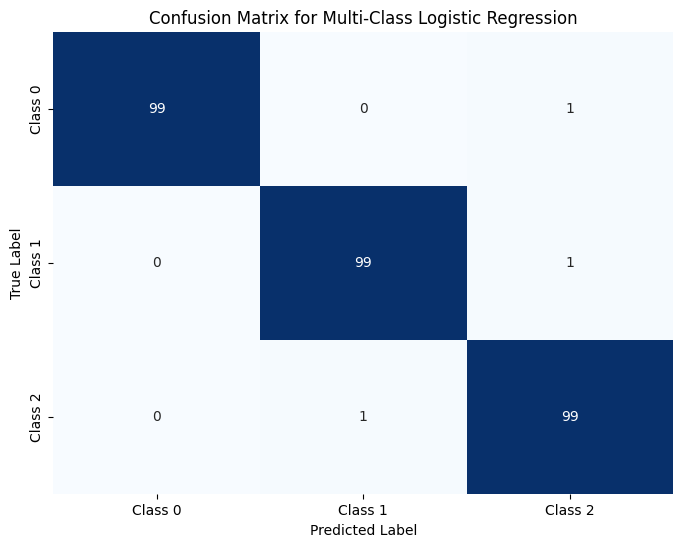

In [19]:
from sklearn.metrics import confusion_matrix

# Calculate the confusion matrix
cm_multi = confusion_matrix(y_multi, y_pred_multi)

print("\nConfusion Matrix (Multi-Class):\n")
print(cm_multi)

# Optionally, you can visualize it (requires matplotlib and seaborn)
import seaborn as sns
plt.figure(figsize=(8, 6))
sns.heatmap(cm_multi, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=[f'Class {i}' for i in range(mclr_model.num_classes)],
            yticklabels=[f'Class {i}' for i in range(mclr_model.num_classes)])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Multi-Class Logistic Regression')
plt.show()

In [7]:
X_multi[0]

array([-1.60262868, -2.11061144])

In [13]:
y_multi[0]

np.int64(0)

In [8]:
X_multi.shape

(300, 2)

In [10]:
mclr_model.weights

array([[-1.04258849,  2.4672815 , -1.42469301],
       [-2.7849625 ,  0.97322799,  1.81173451]])

In [9]:
z = np.dot(X_multi[0,:], mclr_model.weights) + mclr_model.bias
z

array([ 7.81224451, -5.39231954, -2.41992496])

In [12]:
mclr_model.softmax(z.reshape(1,3))

array([[9.99962166e-01, 1.84210451e-06, 3.59922363e-05]])